In [1]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langgraph.graph import START,END,StateGraph
from langchain_community.document_loaders import PyMuPDFLoader
from typing import TypedDict,Annotated,Literal,List,Dict
from pydantic import BaseModel,Field
from jinja2 import Template
from playwright.async_api import async_playwright
import operator

load_dotenv()

/Users/vrund/Desktop/AI-ML/LangGraph/codes/myenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
llm1 = ChatGroq(model="openai/gpt-oss-120b")
llm2 = ChatGroq(model="openai/gpt-oss-20b")

In [3]:
class RoastForgeState(TypedDict):
    pdf_name : str
    pdf_text : str
    roast : str
    ATS_score : int
    improvements : str
    new_resume : dict
    iteration : int

    all_pdf_texts : Annotated[list[str],operator.add]
    all_ats_scores : Annotated[list[int],operator.add]

In [81]:
# class ATSSchema(BaseModel):
#     ATS_score : int = Field(description="give the Score to this resume text/dict.",ge=0,le=100)

# llm_ats = llm2.with_structured_output(ATSSchema)

In [4]:
class ExperienceItem(BaseModel):
    role: str
    company: str
    duration: str
    points: List[str]


class ProjectItem(BaseModel):
    name: str
    stack: str
    points: List[str]


class Skills(BaseModel):
    AI_ML: List[str]
    Dev: List[str]
    Tools: List[str]


class Education(BaseModel):
    degree: str
    college: str
    year: str
    cgpa: str


class ResumeSchema(BaseModel):
    name: str
    title: str
    email: str
    phone: str
    linkedin: str
    github: str
    summary: str
    experience: List[ExperienceItem]
    projects: List[ProjectItem]
    skills: Skills
    education: Education

llm_new_resume = llm1.with_structured_output(ResumeSchema)

In [5]:
def pdf_parser_node(state : RoastForgeState):

    pdf_name = state['pdf_name']
    loader = PyMuPDFLoader(pdf_name)
    pdf_content = loader.load()[0].page_content

    return { 'pdf_text' : pdf_content }

def roast_node(state : RoastForgeState):

    pdf_text = state['pdf_text']
    prompt = f"""
    You are a savage roast comedian.
    You have the profile data in front of you.
    data : {pdf_text}

    based on the resume data, Roast their profile in 3-4 spicy punchy lines.
    Be funny. Be accurate. Be brutal Roaster.
    """
    roast = llm2.invoke(prompt)

    return { 'roast' : roast.content }

def ats_node(state : RoastForgeState):

    if 'new_resume' in state:
        pdf_text = state['new_resume']
    else:
        pdf_text = state['pdf_text']

    prompt = f"""
        You are a brutally honest ATS evaluator for 2026 AI/ML Engineer roles.

        Your job is to analyze the given resume exactly like a strong ATS + technical recruiter screening for AI/ML Engineer, Machine Learning Engineer, Applied AI Engineer, GenAI Engineer, or Data Scientist roles.

        Evaluate the resume based on:

        1. ATS keyword relevance for 2026 AI/ML roles
        2. Technical skills depth (Python, SQL, ML, DL, NLP, LLMs, RAG, Vector DBs, LangChain/LangGraph, FastAPI, Docker, deployment, cloud basics, MLOps basics, Git, APIs, production thinking)
        3. Project quality and real-world impact
        4. Internship / experience relevance
        5. Resume structure and ATS compatibility
        6. Quantified achievements and business impact
        7. Strength of action verbs and clarity
        8. Weaknesses, fluff, redundancy, vague claims
        9. Missing industry expectations for strong candidates in 2026
        10. Overall recruiter shortlisting probability

        Be extremely strict. Do not be polite. Do not inflate scores.

        A mediocre resume should score 45-65, not 80+.

        Breakdown:
        - Keywords Match
        - Technical Depth
        - Projects Strength
        - Experience Quality
        - Resume Structure
        - Impact & Metrics
        - AI/ML Role Fit
        - Production Readiness
        - Competitive Strength
        - Recruiter Shortlist Probability

        no need of explanation, just give score in the integer format.
        ONLY NUMBER FROM 0 to 100.
        Nothing ELSE.
        Now evaluate this resume:

        {pdf_text}
    """
    result = llm2.invoke(prompt)
    ats_score = int(result.content.strip())
    return { 'ATS_score' : ats_score , 'all_ats_scores' : [ats_score]}

def research_node(state : RoastForgeState):

    if 'new_resume' in state:
        pdf_text = state['new_resume']
    else:
        pdf_text = state['pdf_text']

    prompt = f"""
    You are a ruthless senior AI/ML hiring manager reviewing a resume for 2026 AI/ML Engineer roles.

    Your job is to identify exactly what is weak, missing, outdated, vague, or unimpressive in this resume and provide sharp, practical improvement areas that would make the candidate significantly more competitive for AI/ML Engineer, ML Engineer, Applied AI Engineer, GenAI Engineer, and Data Scientist roles.

    Evaluate from the perspective of:
    - Real recruiter screening
    - Strong ATS filtering
    - Technical hiring manager expectations
    - 2026 market standards for AI/ML candidates

    Focus heavily on:
    1. Weak project descriptions
    2. Missing production-level skills
    3. Lack of measurable business impact
    4. Weak internship relevance
    5. Missing GenAI / LLM / RAG / deployment readiness
    6. Weak MLOps understanding
    7. Poor resume wording
    8. Missing quantified achievements
    9. Lack of strong engineering ownership
    10. Missing proof of practical problem-solving

    Do not praise weak work.
    Do not be polite.
    Do not give generic advice like “improve skills” or “do better projects.”

    Be specific and practical.

    Return output ONLY in this exact format:

    Top Improvement Areas:

    1. [Area Name]
    - What is weak:
    - Why it hurts:
    - How to fix it:

    2. [Area Name]
    - What is weak:
    - Why it hurts:
    - How to fix it:

    3. [Area Name]
    - What is weak:
    - Why it hurts:
    - How to fix it:

    4. [Area Name]
    - What is weak:
    - Why it hurts:
    - How to fix it:

    5. [Area Name]
    - What is weak:
    - Why it hurts:
    - How to fix it:

    Priority Order for Fixing:
    1.
    2.
    3.
    4.
    5.

    Final Brutal Verdict:
    (Short direct conclusion on how far this resume is from being truly competitive in 2026)

    Now analyze this resume:

    {pdf_text}
    """

    improvements = llm2.invoke(prompt)
    return { 'improvements' : improvements.content}

def new_resume_node(state : RoastForgeState):

    if 'new_resume' in state:
        pdf_text = state['new_resume']
    else:
        pdf_text = state['pdf_text']

    improvements = state['improvements']

    prompt = f"""
    You are an elite AI resume reconstruction system for 2026 AI/ML Engineer roles.

    Your task is to generate a significantly improved, recruiter-ready, ATS-optimized resume JSON using:

    1. Original resume text
    2. Required improvement analysis

    Your goal is NOT to slightly edit the old resume.
    Your goal is to rebuild it into a much stronger AI/ML Engineer resume that is highly competitive for 2026 hiring standards.

    Target roles:
    - AI/ML Engineer
    - Machine Learning Engineer
    - Applied AI Engineer
    - GenAI Engineer
    - Data Scientist

    You must:

    1. Preserve truthfulness — do not invent fake companies, fake internships, fake degrees, fake achievements, or fake certifications.
    2. Improve weak descriptions into strong recruiter-quality bullet points.
    3. Rewrite vague project descriptions into high-impact production-style statements.
    4. Add quantified impact wherever realistically inferable.
    5. Improve ATS keyword density for 2026 AI/ML roles.
    6. Prioritize modern AI stack:
    Python, SQL, FastAPI, LangChain, LangGraph, RAG, Vector DBs, LLMs, Prompt Engineering, APIs, Docker, Git, Deployment, MLOps basics, OpenCV, Deep Learning, NLP, Production ML thinking.
    7. Remove fluff and weak wording.
    8. Make the resume look like a serious engineering candidate, not a college beginner.
    9. Keep output highly structured and directly usable for PDF generation.
    10. Ensure strong internship + project alignment with AI/ML roles.

    IMPORTANT RULES:

    - No placeholders like "your email here"
    - No hallucinated fake experience
    - Use only realistically supported improvements based on the original resume + improvement analysis

    Now generate the improved resume using:

    resume_text:
    {pdf_text}

    improvement_text:
    {improvements}
    """

    resume_text = llm_new_resume.invoke(prompt)

    return { 'new_resume' : resume_text.model_dump() , 'all_pdf_texts' : [resume_text.model_dump()] }

async def download_pdf_node(state : RoastForgeState):

    new_resume_text = state['new_resume']

    HTML_TEMPLATE = """
    <!DOCTYPE html>
    <html lang="en">
    <head>
    <meta charset="UTF-8"/>
    <style>
    @import url('https://fonts.googleapis.com/css2?family=DM+Sans:wght@300;400;500;600;700&family=DM+Mono:wght@400;500&display=swap');

    * { margin: 0; padding: 0; box-sizing: border-box; }

    body {
        font-family: 'DM Sans', sans-serif;
        font-size: 11px;
        color: #1a1a2e;
        background: white;
        padding: 36px 44px;
        line-height: 1.5;
    }

    /* ── Header ── */
    .header {
        display: flex;
        justify-content: space-between;
        align-items: flex-end;
        border-bottom: 2.5px solid #1a1a2e;
        padding-bottom: 12px;
        margin-bottom: 18px;
    }
    .header-left h1 {
        font-size: 28px;
        font-weight: 700;
        letter-spacing: -0.5px;
        color: #1a1a2e;
    }
    .header-left h2 {
        font-size: 12px;
        font-weight: 400;
        color: #e94560;
        letter-spacing: 2px;
        text-transform: uppercase;
        margin-top: 3px;
    }
    .header-right {
        text-align: right;
        font-family: 'DM Mono', monospace;
        font-size: 9.5px;
        color: #555;
        line-height: 1.8;
    }
    .header-right a { color: #555; text-decoration: none; }

    /* ── Section ── */
    .section { margin-bottom: 16px; }
    .section-title {
        font-size: 9px;
        font-weight: 700;
        letter-spacing: 3px;
        text-transform: uppercase;
        color: #e94560;
        margin-bottom: 8px;
        padding-bottom: 3px;
        border-bottom: 1px solid #e8e8e8;
    }

    /* ── Summary ── */
    .summary { color: #333; font-size: 10.5px; }

    /* ── Experience / Projects ── */
    .item { margin-bottom: 10px; }
    .item-header {
        display: flex;
        justify-content: space-between;
        align-items: baseline;
    }
    .item-title {
        font-weight: 600;
        font-size: 11px;
        color: #1a1a2e;
    }
    .item-sub {
        font-size: 9.5px;
        color: #777;
        font-family: 'DM Mono', monospace;
    }
    .item-stack {
        font-family: 'DM Mono', monospace;
        font-size: 8.5px;
        color: #e94560;
        margin: 2px 0 4px;
    }
    ul { padding-left: 14px; }
    ul li {
        font-size: 10px;
        color: #333;
        margin-bottom: 2px;
    }

    /* ── Skills ── */
    .skills-grid {
        display: grid;
        grid-template-columns: repeat(3, 1fr);
        gap: 8px;
    }
    .skill-group-title {
        font-size: 9px;
        font-weight: 600;
        text-transform: uppercase;
        letter-spacing: 1px;
        color: #1a1a2e;
        margin-bottom: 4px;
    }
    .skill-tags { display: flex; flex-wrap: wrap; gap: 4px; }
    .tag {
        background: #f0f0f5;
        border: 1px solid #ddd;
        border-radius: 3px;
        padding: 2px 7px;
        font-size: 9px;
        font-family: 'DM Mono', monospace;
        color: #333;
    }

    /* ── Education ── */
    .edu-row {
        display: flex;
        justify-content: space-between;
        align-items: baseline;
    }
    .edu-degree { font-weight: 600; font-size: 11px; }
    .edu-college { font-size: 10px; color: #555; margin-top: 2px; }
    .edu-meta {
        font-family: 'DM Mono', monospace;
        font-size: 9.5px;
        color: #e94560;
        text-align: right;
    }

    /* ── Footer line ── */
    .footer {
        margin-top: 20px;
        border-top: 1px solid #e8e8e8;
        padding-top: 6px;
        font-size: 8px;
        color: #bbb;
        font-family: 'DM Mono', monospace;
        text-align: center;
    }
    </style>
    </head>
    <body>

    <!-- HEADER -->
    <div class="header">
    <div class="header-left">
        <h1>{{ name }}</h1>
        <h2>{{ title }}</h2>
    </div>
    <div class="header-right">
        <div>{{ email }}</div>
        <div>{{ phone }}</div>
        <div>{{ linkedin }}</div>
        <div>{{ github }}</div>
    </div>
    </div>

    <!-- SUMMARY -->
    <div class="section">
    <div class="section-title">Profile</div>
    <p class="summary">{{ summary }}</p>
    </div>

    <!-- EXPERIENCE -->
    <div class="section">
    <div class="section-title">Experience</div>
    {% for exp in experience %}
    <div class="item">
        <div class="item-header">
        <span class="item-title">{{ exp.role }} — {{ exp.company }}</span>
        <span class="item-sub">{{ exp.duration }}</span>
        </div>
        <ul>
        {% for point in exp.points %}<li>{{ point }}</li>{% endfor %}
        </ul>
    </div>
    {% endfor %}
    </div>

    <!-- PROJECTS -->
    <div class="section">
    <div class="section-title">Projects</div>
    {% for proj in projects %}
    <div class="item">
        <div class="item-title">{{ proj.name }}</div>
        <div class="item-stack">{{ proj.stack }}</div>
        <ul>
        {% for point in proj.points %}<li>{{ point }}</li>{% endfor %}
        </ul>
    </div>
    {% endfor %}
    </div>

    <!-- SKILLS -->
    <div class="section">
    <div class="section-title">Skills</div>
    <div class="skills-grid">
        {% for group, items in skills.items() %}
        <div>
        <div class="skill-group-title">{{ group }}</div>
        <div class="skill-tags">
            {% for s in items %}<span class="tag">{{ s }}</span>{% endfor %}
        </div>
        </div>
        {% endfor %}
    </div>
    </div>

    <!-- EDUCATION -->
    <div class="section">
    <div class="section-title">Education</div>
    <div class="edu-row">
        <div>
        <div class="edu-degree">{{ education.degree }}</div>
        <div class="edu-college">{{ education.college }}</div>
        </div>
        <div class="edu-meta">
        <div>{{ education.year }}</div>
        <div>CGPA {{ education.cgpa }}</div>
        </div>
    </div>
    </div>

    <div class="footer">Generated by RoastForge · AI Resume Rebuilder</div>

    </body>
    </html>
    """

# def render_html(data: dict) -> str:
    template = Template(HTML_TEMPLATE)
    html = template.render(new_resume_text)
    file_path = '1roastForgeResume.pdf'

# ── 4. Convert HTML → PDF with Playwright ──
# async def generate_pdf(html: str, output_path: str):
    async with async_playwright() as p:
        browser = await p.chromium.launch()
        page = await browser.new_page()
        await page.set_content(html, wait_until="networkidle")  # wait for fonts
        await page.pdf(
            path=file_path,
            format="A4",
            margin={"top": "0", "bottom": "0", "left": "0", "right": "0"},
            print_background=True,
        )
        await browser.close()

    # html = render_html(new_resume_text)
    # await generate_pdf(html, f"roastforged.pdf")


def end_or_not(state : RoastForgeState):

    ats_score = state['ATS_score']
    i = state['iteration']

    if (ats_score > 80 and state['new_resume']) or i >= 3 :
        return 'download_pdf'
    elif ats_score > 80:
        return 'good'
    else:
        i += 1
        return 'not_good'

In [6]:
graph = StateGraph(RoastForgeState)

graph.add_node("pdf_parser_node",pdf_parser_node)
graph.add_node("roast_node",roast_node)
graph.add_node("ats_node",ats_node)
graph.add_node("research_node",research_node)
graph.add_node("new_resume_node",new_resume_node)
graph.add_node("download_pdf_node",download_pdf_node)

graph.add_edge(START,"pdf_parser_node")
graph.add_edge("pdf_parser_node","ats_node")
graph.add_edge("pdf_parser_node","roast_node")
graph.add_conditional_edges("ats_node",end_or_not,{ 'good' : END , 'not_good' : 'research_node' , 'download_pdf' : 'download_pdf_node'})
graph.add_edge("research_node","new_resume_node")
graph.add_edge("new_resume_node","ats_node")

roastforge = graph.compile()

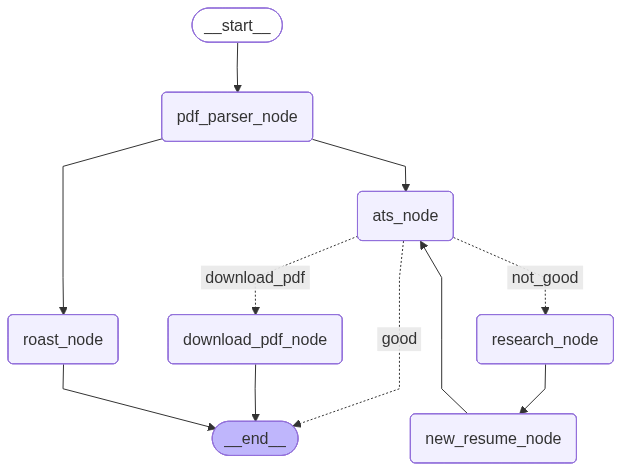

In [7]:
roastforge

In [8]:
initial_state = {
    'pdf_name' : 'cv.pdf',
    'iteration' : 1
}

result = await roastforge.ainvoke(initial_state)

In [9]:
result

{'pdf_name': 'cv.pdf',
 'pdf_text': 'Vrund Patel\n# vrund765patel@gmail.com | \x83 +917984825372 | ï Vrund Patel | § Vrund2005\nSummary\nAI/ML Engineer with internship experience at Bacancy, focused on building real-world AI systems using GenAI,\nautomation, and machine learning. Skilled in developing RAG pipelines, LLM-powered workflows, and scalable\ndata-driven solutions using Python.\nEducation\nBE : Vishwakarma Government Engineering College\nComputer Science & Engineering (Data Science)\n2022 – 2026\n• CGPA : 9.36\nHSC : Swastik Education Campus(GSEB Board)\n2022\n• Percentage : 88.67% , Percentile : 96.83\nSSC : Swastik Education Campus(GSEB Board)\n2020\n• Percentage : 85.17%\nExperience\nAI/ML Engineer Intern — Bacancy Technology\nz Jan 2026 – Apr 2026\n• Worked on real-world ML and computer vision tasks, including model development, preprocessing, and\noptimization.\n• Built and experimented with CNNs and classical ML models for classification problems.\n• Applied OpenCV for 